# Uber Trip Analysis & Demand Prediction

**Objective:** To analyze aggregated daily Uber trip statistics from January and February 2015 to identify patterns and build a predictive machine learning model for trip demand. 

As a Data Analyst, predicting ride demand is crucial for optimizing fleet deployment. In this project, we will map the raw TLC dispatch base codes to their actual company names (e.g., Unter, Grun), engineer time-based features, and train a Random Forest Regressor to forecast the total number of trips.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### 1. Data Preprocessing
First, we load the Freedom of Information Law (FOIL) dataset. Machine learning models require clean, structured data, so we will convert the raw date strings into proper datetime objects. We also map the alphanumeric dispatching base numbers (like B02512) to their actual company names to make our analysis readable for business stakeholders.

In [2]:
data = pd.read_csv('Uber-Jan-Feb-FOIL.csv')
data['date'] = pd.to_datetime(data['date'])

In [6]:
base_mapping = {
    'B02512': 'Unter', 'B02598': 'Hinter', 'B02617': 'Weiter', 
    'B02682': 'Schmecken', 'B02764': 'Danach-NY', 'B02765': 'Grun'
}
data['Base_Name'] = data['dispatching_base_number'].map(base_mapping)

In [7]:
print(f"Dataset loaded successfully. Shape: {data.shape}")
display(data.head(3))

Dataset loaded successfully. Shape: (354, 6)


,dispatching_base_number,date,active_vehicles,trips,Base_Name,DayOfWeek
0,B02512,2015-01-01,190,1132,Unter,3
1,B02765,2015-01-01,225,1765,Grun,3
2,B02764,2015-01-01,3427,29421,Danach-NY,3


### 2. Exploratory Data Analysis (EDA)
Before building a predictive model, we must understand the underlying demand patterns in our data. 

In this section, we visualize:
1. **Average Trips by Day of the Week:** To identify which days experience peak ride demand.
2. **Trips per Dispatch Base:** To see which specific Uber base handles the highest volume.
3. **Active Vehicles vs. Total Trips:** To verify the linear correlation between fleet size and completed rides.

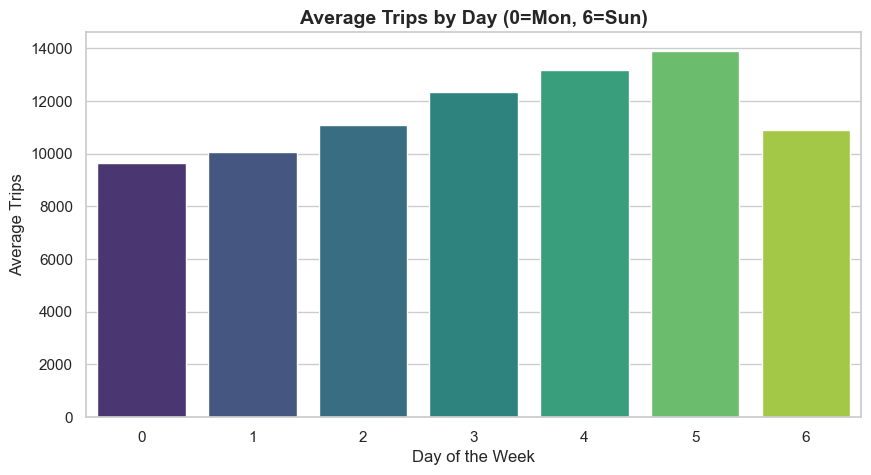

In [12]:
plt.figure(figsize=(10, 5))
data['DayOfWeek'] = data['date'].dt.dayofweek
sns.barplot(x='DayOfWeek', y='trips', data=data, ci=None, palette='viridis')

plt.title('Average Trips by Day (0=Mon, 6=Sun)', weight='bold', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Trips', fontsize=12)
plt.show()

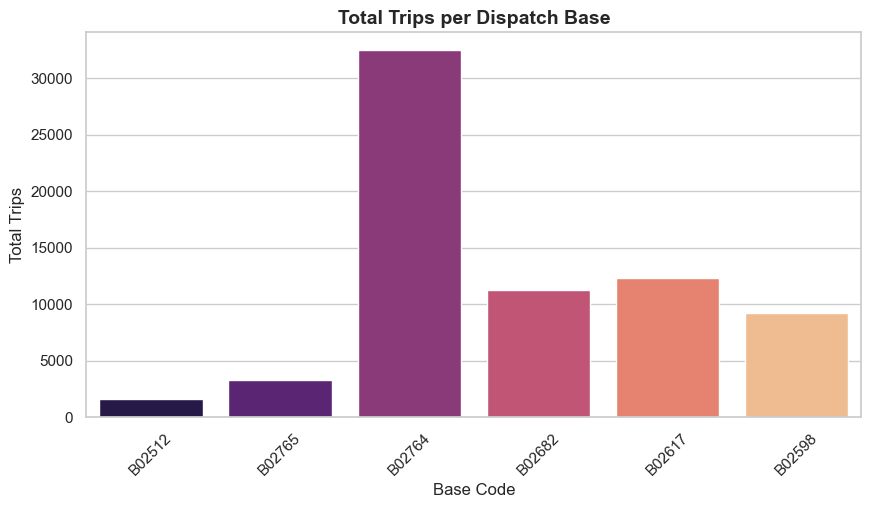

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x='dispatching_base_number', y='trips', data=data, ci=None, palette='magma')

plt.title('Total Trips per Dispatch Base', weight='bold', fontsize=14)
plt.xlabel('Base Code', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.xticks(rotation=45)
plt.show()

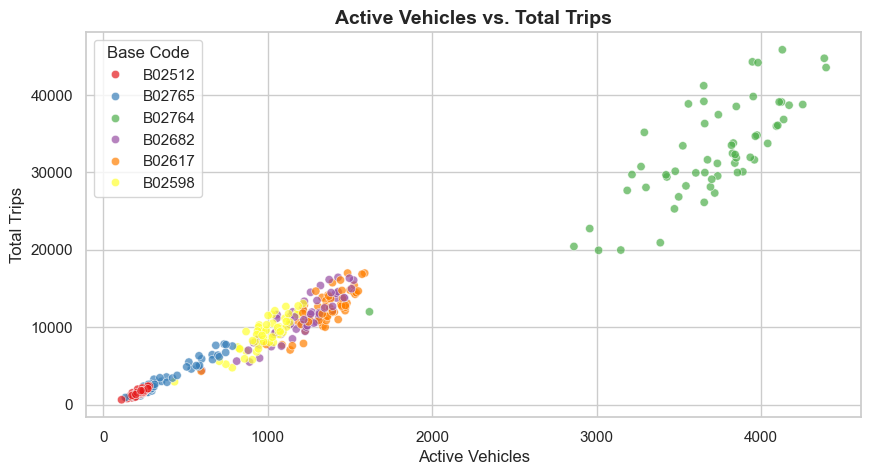

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='active_vehicles', y='trips', data=data, hue='dispatching_base_number', palette='Set1', alpha=0.7)

plt.title('Active Vehicles vs. Total Trips', weight='bold', fontsize=14)
plt.xlabel('Active Vehicles', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.legend(title='Base Code')
plt.show()

### 3. Feature Engineering
Our predictive algorithm cannot process raw dates or text strings. We must transform our data:
* **Time Features:** We extract the exact `Day` and `Month` from our datetime column.
* **One-Hot Encoding:** We convert our categorical `Base_Name` column into multiple binary (0 or 1) columns using `pd.get_dummies()`. This allows the mathematical model to understand which company base is handling the trips.

In [15]:
data['Day'] = data['date'].dt.day
data['Month'] = data['date'].dt.month


In [16]:
data_encoded = pd.get_dummies(data, columns=['Base_Name'], drop_first=True)

In [17]:
X = data_encoded.drop(columns=['date', 'dispatching_base_number', 'trips'])
y = data_encoded['trips']

print("Features Prepared for Modeling:")
print(X.columns.tolist())

Features Prepared for Modeling:
['active_vehicles', 'DayOfWeek', 'Day', 'Month', 'Base_Name_Grun', 'Base_Name_Hinter', 'Base_Name_Schmecken', 'Base_Name_Unter', 'Base_Name_Weiter']


### 4 & 5. Model Building and Evaluation
We split our processed dataset into a Training set (70%) and a Testing set (30%). 

We are utilizing a **Random Forest Regressor**, which is an advanced ensemble algorithm that builds multiple decision trees and merges them to get a highly accurate and stable prediction. After training, we evaluate the model's accuracy using Mean Absolute Error (MAE), Mean Squared Error (MSE), and the R-Squared (R2) score.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [20]:
y_pred = rfr.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [22]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"R-Squared Score (R2):      {r2:.4f}")

Mean Absolute Error (MAE): 826.74
Mean Squared Error (MSE):  1591813.34
R-Squared Score (R2):      0.9868


### 6. Visualization: Actual vs Predicted Trips
To conclude our analysis, we plot the Random Forest model's predicted trip counts directly against the actual historical trip counts. The closer our data points sit to the red "Perfect Prediction" line, the more accurate our algorithm is at forecasting Uber demand.

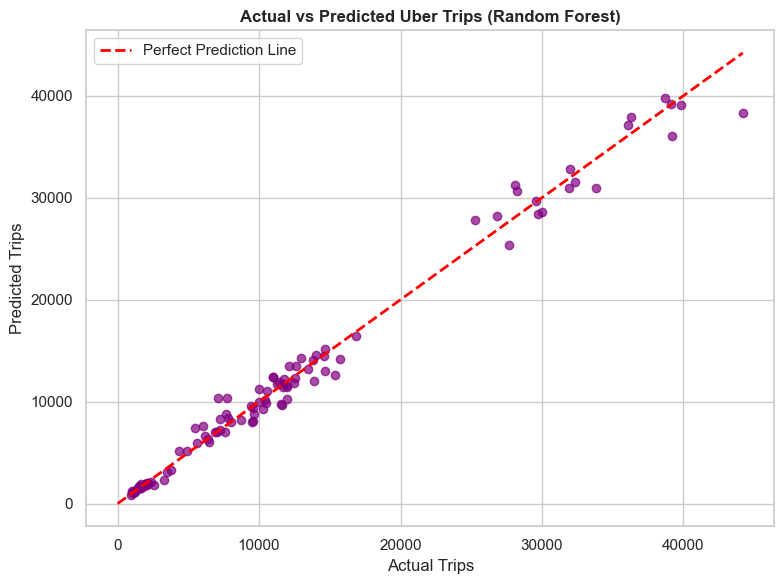

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], '--', color='red', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs Predicted Uber Trips (Random Forest)', weight='bold')
plt.xlabel('Actual Trips')
plt.ylabel('Predicted Trips')
plt.legend()
plt.tight_layout()
plt.show()

### 7. Custom Scenario Testing (Model Inference)
To demonstrate the practical business value of this model, we will run a custom test. We will input a hypothetical scenario (dummy values) to see how many trips the model predicts. 

For example, we want to forecast demand for a **Monday (DayOfWeek = 0)** in **February (Month = 2)**, assuming we have exactly **500 active vehicles** deployed under the **B02764** dispatch base.

In [25]:
scenario_data = {
    'active_vehicles': [500],
    'Day': [15],          # 15th of the month
    'Month': [2],         # February
    'DayOfWeek': [0],     # 0 = Monday
}

dummy_df = pd.DataFrame(scenario_data)
dummy_df = dummy_df.reindex(columns=X.columns, fill_value=0)

In [26]:
if 'dispatching_base_number_B02764' in dummy_df.columns:
    dummy_df['dispatching_base_number_B02764'] = 1

In [27]:
predicted_trips = rfr.predict(dummy_df)

print("--- CUSTOM SCENARIO TEST ---")
print(f"Active Vehicles : 500")
print(f"Day of Week     : Monday")
print(f"Month           : February")
print("-" * 28)
print(f"PREDICTED TRIPS : {int(predicted_trips[0])} trips")

--- CUSTOM SCENARIO TEST ---
Active Vehicles : 500
Day of Week     : Monday
Month           : February
----------------------------
PREDICTED TRIPS : 5019 trips
